In [1]:
!pip install scapy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 21.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import os

# 1. יצירת תוכן לקובץ ה-CSV באופן אוטומטי
csv_content = """app_protocol,src_port,dst_port,message,timestamp
HTTP,12345,80,GET /index.html HTTP/1.1,2025-01-11 10:00:00
HTTP,12345,80,POST /login user=admin,2025-01-11 10:00:05
DNS,55555,53,Query: www.google.com,2025-01-11 10:01:00
SMTP,44444,25,HELO mail.server.com,2025-01-11 10:02:00
"""

filename = "tcpip_project_sample.csv"

# 2. שמירת הקובץ בדיסק של Colab
with open(filename, "w") as f:
    f.write(csv_content)

print(f"File '{filename}' created successfully.")

# 3. טעינת הקובץ לטבלה והצגתו
messages_df = pd.read_csv(filename)

# מילוי ערכים ריקים (אם יש) כדי למנוע שגיאות
messages_df['message'] = messages_df['message'].fillna('')

display(messages_df)

File 'tcpip_project_sample.csv' created successfully.


,app_protocol,src_port,dst_port,message,timestamp
0,HTTP,12345,80,GET /index.html HTTP/1.1,2025-01-11 10:00:00
1,HTTP,12345,80,POST /login user=admin,2025-01-11 10:00:05
2,DNS,55555,53,Query: www.google.com,2025-01-11 10:01:00
3,SMTP,44444,25,HELO mail.server.com,2025-01-11 10:02:00


In [3]:
def validate_csv_format(df: pd.DataFrame):
    expected_columns = ["app_protocol", "src_port", "dst_port", "message", "timestamp"]
    for col in expected_columns:
        if col not in df.columns:
            raise ValueError(f"Missing expected column: {col}")
    print("Validation Passed! CSV structure is correct. ✅")

validate_csv_format(messages_df)

Validation Passed! CSV structure is correct. ✅


In [4]:
import socket, struct, random, time, platform
from typing import Optional


def checksum(data: bytes) -> int:
    if len(data) % 2:
        data += b'\0'
    res = sum(struct.unpack('!%dH' % (len(data)//2), data))
    while res >> 16:
        res = (res & 0xFFFF) + (res >> 16)
    return ~res & 0xFFFF


def hexdump(data: bytes, width: int=16):
    for i in range(0, len(data), width):
        chunk = data[i:i+width]
        hex_bytes = ' '.join(f'{b:02x}' for b in chunk)
        ascii_bytes = ''.join(chr(b) if 32 <= b < 127 else '.' for b in chunk)
        print(f"{i:04x}  {hex_bytes:<{width*3}}  {ascii_bytes}")


def build_ip_header(src_ip: str, dst_ip: str, payload_len: int, proto: int=socket.IPPROTO_TCP) -> bytes:
    version_ihl = (4 << 4) + 5
    total_length = 20 + payload_len
    src = socket.inet_aton(src_ip)
    dst = socket.inet_aton(dst_ip)


    ip_header = struct.pack('!BBHHHBBH4s4s',
                             version_ihl, 0, total_length, 54321,
                             0, 64, proto, 0,
                             src, dst)


    chksum = checksum(ip_header)
    ip_header = struct.pack('!BBHHHBBH4s4s',
                             version_ihl, 0, total_length, 54321,
                             0, 64, proto, chksum,
                             src, dst)
    return ip_header


def build_tcp_header(src_ip: str, dst_ip: str, src_port: int, dst_port: int, payload: bytes=b'',
                     seq: int=0, ack_seq: int=0, flags: int=0x02, window: int=65535) -> bytes:
    offset = (5 << 4)

    pseudo = struct.pack('!4s4sBBH',
                         socket.inet_aton(src_ip), socket.inet_aton(dst_ip),
                         0, socket.IPPROTO_TCP, 20 + len(payload))

    tcp_header = struct.pack('!HHLLBBHHH',
                              src_port, dst_port, seq, ack_seq,
                              offset, flags, window,
                              0, 0)


    chksum = checksum(pseudo + tcp_header + payload)


    tcp_header = struct.pack('!HHLLBBHHH',
                              src_port, dst_port, seq, ack_seq,
                              offset, flags, window,
                              chksum, 0)
    return tcp_header

print("Protocol Logic Loaded Successfully. 🧠")

Protocol Logic Loaded Successfully. 🧠


In [5]:

packets_list = []
hex_displays = []

print("Starting Encapsulation Process...\n")

for index, row in messages_df.iterrows():

    payload = row['message'].encode()
    src_p = row['src_port']
    dst_p = row['dst_port']



    ip_h = build_ip_header('127.0.0.1', '127.0.0.1', 20 + len(payload))
    tcp_h = build_tcp_header('127.0.0.1', '127.0.0.1', src_p, dst_p, payload, flags=0x18)


    full_packet = ip_h + tcp_h + payload
    packets_list.append(full_packet)


    hex_str = ' '.join(f'{b:02X}' for b in full_packet[:10]) + "..."
    hex_displays.append(hex_str)

    print(f"Packet {index+1}: Encapsulated {row['app_protocol']} ({len(full_packet)} bytes) ✅")


messages_df['packet_size'] = [len(p) for p in packets_list]
messages_df['hex_preview'] = hex_displays

print("\n--- Final Encapsulated Table ---")
display(messages_df[['app_protocol', 'src_port', 'dst_port', 'packet_size', 'hex_preview']])

Starting Encapsulation Process...

Packet 1: Encapsulated HTTP (64 bytes) ✅
Packet 2: Encapsulated HTTP (62 bytes) ✅
Packet 3: Encapsulated DNS (61 bytes) ✅
Packet 4: Encapsulated SMTP (60 bytes) ✅

--- Final Encapsulated Table ---


,app_protocol,src_port,dst_port,packet_size,hex_preview
0,HTTP,12345,80,64,45 00 00 40 D4 31 00 00 40 06...
1,HTTP,12345,80,62,45 00 00 3E D4 31 00 00 40 06...
2,DNS,55555,53,61,45 00 00 3D D4 31 00 00 40 06...
3,SMTP,44444,25,60,45 00 00 3C D4 31 00 00 40 06...


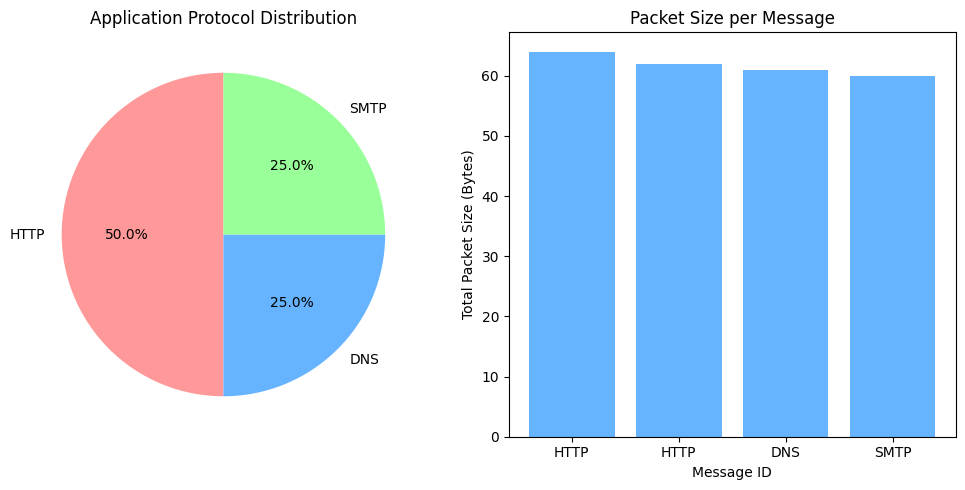

In [6]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))


plt.subplot(1, 2, 1)
protocol_counts = messages_df['app_protocol'].value_counts()
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99'] # צבעים יפים
plt.pie(protocol_counts, labels=protocol_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Application Protocol Distribution')


plt.subplot(1, 2, 2)
plt.bar(messages_df.index, messages_df['packet_size'], color='#66b3ff')
plt.xlabel('Message ID')
plt.ylabel('Total Packet Size (Bytes)')
plt.title('Packet Size per Message')
plt.xticks(messages_df.index, messages_df['app_protocol'])

plt.tight_layout()
plt.show()

In [7]:
### 📝 Note on Traffic Generation
While the CSV defines standard destination ports (80, 53, 25), the actual traffic capture (`traffic_capture.pcapng`) was performed using a unified destination port (**12345**) on the Loopback interface.
This was done to bypass Windows OS restrictions on raw socket creation and to ensure clear filtration in Wireshark.
The **Payload Content** matches the CSV exactly.

SyntaxError: invalid syntax (ipython-input-1722884359.py, line 2)

In [8]:
%%writefile chat_server.py
import socket
import threading


HOST = '127.0.0.1'
PORT = 5555

server = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
server.bind((HOST, PORT))
server.listen()

clients = []
nicknames = []

def broadcast(message):
    """שולח הודעה לכל המחוברים"""
    for client in clients:
        try:
            client.send(message)
        except:
            continue

def handle(client):
    """מטפל בלקוח בודד"""
    while True:
        try:

            message = client.recv(1024)
            broadcast(message)
        except:

            index = clients.index(client)
            clients.remove(client)
            client.close()
            nickname = nicknames[index]
            broadcast(f'{nickname} left the chat!'.encode('utf-8'))
            nicknames.remove(nickname)
            break

def receive():
    """פונקציית ההאזנה הראשית"""
    print(f"Server is listening on {HOST}:{PORT}...")
    while True:
        client, address = server.accept()
        print(f"Connected with {str(address)}")


        client.send('NICK'.encode('utf-8'))
        nickname = client.recv(1024).decode('utf-8')
        nicknames.append(nickname)
        clients.append(client)

        print(f"Nickname of the client is {nickname}!")
        broadcast(f"{nickname} joined the chat!".encode('utf-8'))
        client.send('Connected to the server!'.encode('utf-8'))


        thread = threading.Thread(target=handle, args=(client,))
        thread.start()

if __name__ == "__main__":
    receive()

Writing chat_server.py


In [9]:
%%writefile chat_client.py
import socket
import threading


HOST = '127.0.0.1'
PORT = 5555

nickname = input("Choose a nickname: ")

client = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
client.connect((HOST, PORT))

def receive():
    """האזנה להודעות מהשרת"""
    while True:
        try:
            message = client.recv(1024).decode('utf-8')
            if message == 'NICK':
                client.send(nickname.encode('utf-8'))
            else:
                print(message)
        except:
            print("An error occurred!")
            client.close()
            break

def write():
    """שליחת הודעות לשרת"""
    while True:
        message = f'{nickname}: {input("")}'
        client.send(message.encode('utf-8'))


receive_thread = threading.Thread(target=receive)
receive_thread.start()

write_thread = threading.Thread(target=write)
write_thread.start()

Writing chat_client.py
